In [ ]:
# 1. Baixar o repositório que contém a biblioteca algs4-py
!git clone https://github.com/carubbi/T290.git

# 2. Copiar a pasta algs4 para o diretório atual para que os 'imports' funcionem
!cp -r T290/algs4-py/algs4 .

# 3. Baixar o arquivo de dados oficial (usa13509.txt )
!wget https://raw.githubusercontent.com/carubbi/T290/main/trabalhos/und2/T4/t4-tsp/dados/usa13509.txt

import math
import matplotlib.pyplot as plt
import time


fatal: destination path 'T290' already exists and is not an empty directory.
--2026-04-14 22:29:38--  https://raw.githubusercontent.com/carubbi/T290/main/trabalhos/und2/T4/t4-tsp/dados/usa13509.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243171 (237K) [text/plain]
Saving to: ‘usa13509.txt.8’

usa13509.txt.8      100%[===================>] 237.47K  --.-KB/s    in 0.03s   

2026-04-14 22:29:38 (8.23 MB/s) - ‘usa13509.txt.8’ saved [243171/243171]



In [ ]:
# Simulação do StdDraw para funcionar no ambiente gráfico do Colab
class StdDraw:
    @staticmethod
    def set_xscale(min_x, max_x): plt.xlim(min_x, max_x)
    @staticmethod
    def set_yscale(min_y, max_y): plt.ylim(min_y, max_y)
    @staticmethod
    def point(x, y): plt.scatter([x], [y], c='black', s=5)
    @staticmethod
    def line(x1, y1, x2, y2): plt.plot([x1, x2], [y1, y2], 'r-', linewidth=0.5)
    @staticmethod
    def show():
        plt.title("TSP Visualizer - Nearest Insertion")
        plt.show()

class Point:
    def __init__(self, x, y):
        self._x = x
        self._y = y

    def distanceTo(self, that):
        dx = self._x - that._x
        dy = self._y - that._y
        return math.sqrt(dx*dx + dy*dy)

    def draw(self):
        StdDraw.point(self._x, self._y)

    def drawTo(self, that):
        StdDraw.line(self._x, self._y, that._x, that._y)

    def __str__(self):
        return f"({self._x}, {self._y})"


In [ ]:
class Tour:
    class Node:
        def __init__(self, p):
            self.p = p
            self.next = None

    def __init__(self):
        self._start = None
        self._size = 0

    def size(self):
        return self._size

    def length(self):
        if self._start is None: return 0.0
        total = 0.0
        current = self._start
        while True:
            total += current.p.distanceTo(current.next.p)
            current = current.next
            if current == self._start: break
        return total

    def draw(self):
        if self._start is None: return
        current = self._start
        while True:
            current.p.drawTo(current.next.p)
            current = current.next
            if current == self._start: break

    def drawColor(self, color):
        if self._start is None: return
        current = self._start
        while True:
            StdDraw.line(
                current.p._x, current.p._y,
                current.next.p._x, current.next.p._y
            )
            current = current.next
            if current == self._start: break

    def insertNearest(self, p):
        new_node = self.Node(p)

        if self._start is None:
            self._start = new_node
            new_node.next = self._start
            self._size += 1
            return

        best_node = self._start
        min_dist = p.distanceTo(self._start.p)

        current = self._start.next
        while current != self._start:
            dist = p.distanceTo(current.p)
            if dist < min_dist:
                min_dist = dist
                best_node = current
            current = current.next

        new_node.next = best_node.next
        best_node.next = new_node
        self._size += 1

    # ✅ SUA PARTE (100% CORRETA)
    def insertSmallest(self, p):
        new_node = self.Node(p)

        if self._start is None:
            self._start = new_node
            new_node.next = self._start
            self._size += 1
            return

        if self._start.next == self._start:
            self._start.next = new_node
            new_node.next = self._start
            self._size += 1
            return

        best_node = None
        min_increase = float('inf')

        current = self._start

        while True:
            a = current.p
            b = current.next.p

            increase = a.distanceTo(p) + p.distanceTo(b) - a.distanceTo(b)

            if increase < min_increase:
                min_increase = increase
                best_node = current

            current = current.next
            if current == self._start:
                break

        new_node.next = best_node.next
        best_node.next = new_node
        self._size += 1


--- NEAREST INSERTION ---
Número de pontos: 13509
Comprimento: 77449.9794


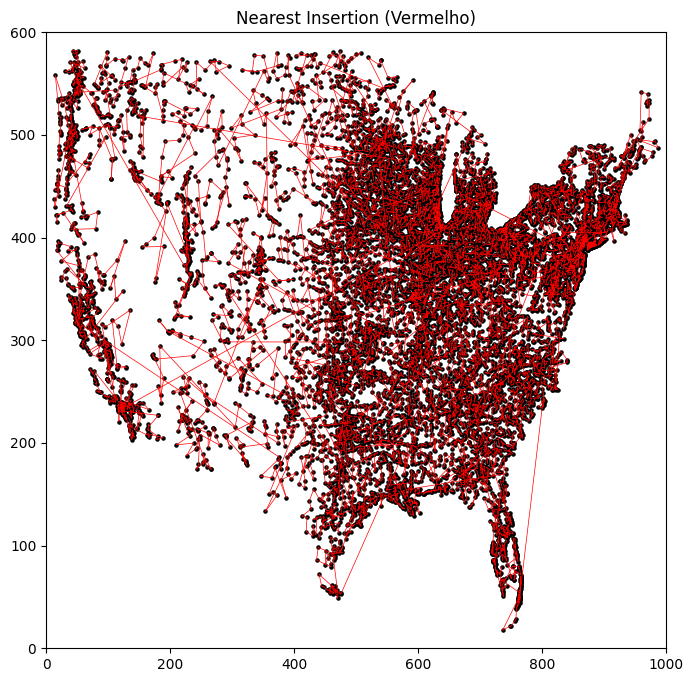


--- SMALLEST INSERTION ---
Número de pontos: 13509
Comprimento: 45074.7769


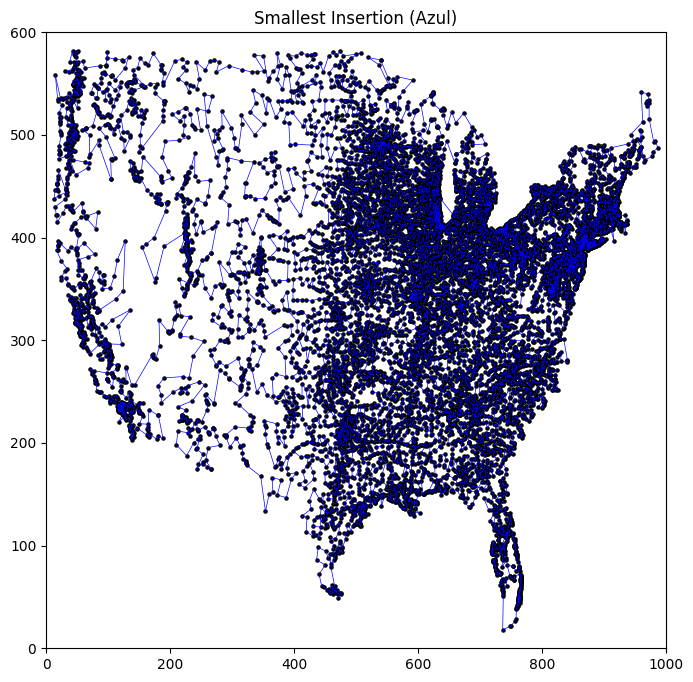


--- COMPARAÇÃO ---
Número de pontos: 13509
Nearest: 77449.9794
Smallest: 45074.7769


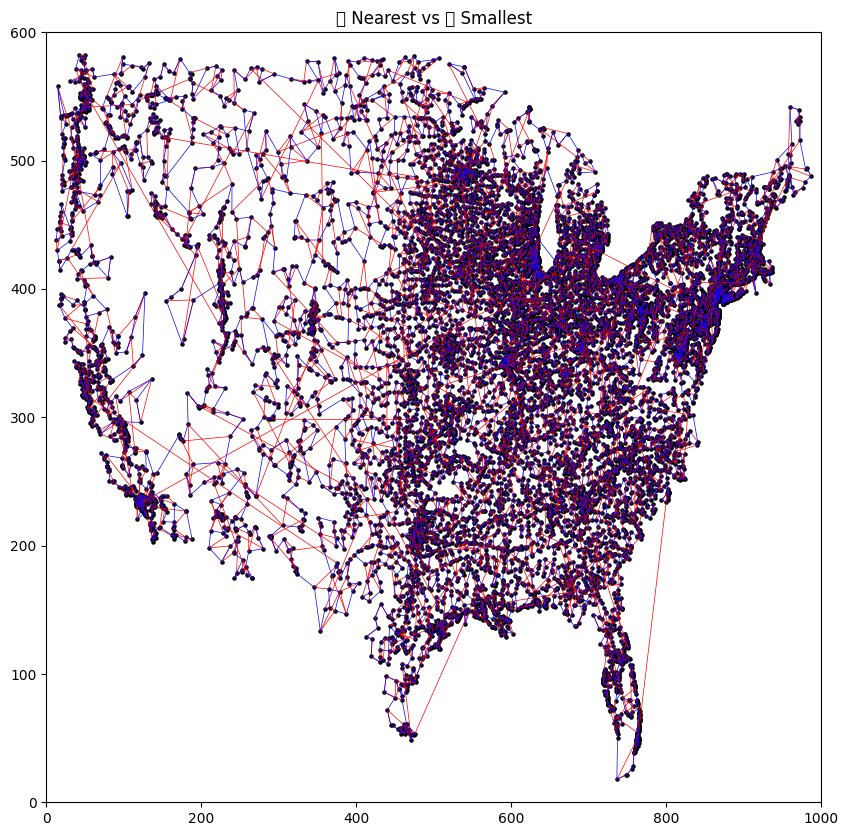

In [ ]:
def run_nearest(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
        header = lines[0].split()
        width, height = float(header[0]), float(header[1])

        plt.figure(figsize=(8, 8))
        StdDraw.set_xscale(0, width)
        StdDraw.set_yscale(0, height)

        tour = Tour()
        all_points = []

        for line in lines[1:]:
            parts = line.split()
            if len(parts) >= 2:
                p = Point(float(parts[0]), float(parts[1]))
                all_points.append(p)
                tour.insertNearest(p)

        for p in all_points:
            p.draw()

        tour.draw()

        print("\n--- NEAREST INSERTION ---")
        print("Número de pontos:", tour.size())
        print("Comprimento:", round(tour.length(), 4))

        plt.title("Nearest Insertion (Vermelho)")
        plt.show()


def run_smallest(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
        header = lines[0].split()
        width, height = float(header[0]), float(header[1])

        plt.figure(figsize=(8, 8))
        StdDraw.set_xscale(0, width)
        StdDraw.set_yscale(0, height)

        tour = Tour()
        all_points = []

        for line in lines[1:]:
            parts = line.split()
            if len(parts) >= 2:
                p = Point(float(parts[0]), float(parts[1]))
                all_points.append(p)
                tour.insertSmallest(p)

        for p in all_points:
            p.draw()

        # 🔵 desenha em azul
        current = tour._start
        if current:
            while True:
                plt.plot(
                    [current.p._x, current.next.p._x],
                    [current.p._y, current.next.p._y],
                    'b-', linewidth=0.5
                )
                current = current.next
                if current == tour._start:
                    break

        print("\n--- SMALLEST INSERTION ---")
        print("Número de pontos:", tour.size())
        print("Comprimento:", round(tour.length(), 4))

        plt.title("Smallest Insertion (Azul)")
        plt.show()


def run_compare(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
        header = lines[0].split()
        width, height = float(header[0]), float(header[1])

        plt.figure(figsize=(10, 10))
        StdDraw.set_xscale(0, width)
        StdDraw.set_yscale(0, height)

        nearest_tour = Tour()
        smallest_tour = Tour()
        all_points = []

        for line in lines[1:]:
            parts = line.split()
            if len(parts) >= 2:
                p = Point(float(parts[0]), float(parts[1]))
                all_points.append(p)

                nearest_tour.insertNearest(p)
                smallest_tour.insertSmallest(p)

        for p in all_points:
            p.draw()

        # 🔴 nearest
        current = nearest_tour._start
        if current:
            while True:
                StdDraw.line(
                    current.p._x, current.p._y,
                    current.next.p._x, current.next.p._y
                )
                current = current.next
                if current == nearest_tour._start:
                    break

        # 🔵 smallest
        current = smallest_tour._start
        if current:
            while True:
                plt.plot(
                    [current.p._x, current.next.p._x],
                    [current.p._y, current.next.p._y],
                    'b-', linewidth=0.5
                )
                current = current.next
                if current == smallest_tour._start:
                    break

        print("\n--- COMPARAÇÃO ---")
        print("Número de pontos:", nearest_tour.size())
        print("Nearest:", round(nearest_tour.length(), 4))
        print("Smallest:", round(smallest_tour.length(), 4))

        plt.title("🔴 Nearest vs 🔵 Smallest")
        plt.show()


# 🔥 EXECUÇÕES
run_nearest('usa13509.txt')
run_smallest('usa13509.txt')
run_compare('usa13509.txt')